<a href="https://colab.research.google.com/github/080304/WPT_Analysis_No_Compensation/blob/main/WPT_Analysis_No_Compensation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Adinni Salsabillah

NIM  : 225150307111014

**Pemodelan Rangkaian WPT**

Rangkaian terdiri dari
1.   2 kumparan (LT dan LR) dengan kopling magnetik (K = 0.6)
2.   Sumber tegangan AC V1 dengan bentuk gelombang SINE(0 12 582193)
3. Resistor R1 (1.2Ω) seri dengan kumparan transmitter (LT)
4. Resistor R2 (1.6Ω) seri dengan kumparan receiver (LR)
5. Beban resistor RB (1kΩ)

### 1. Analisis KCL & KVL (Hukum Kirchoff)

**Persamaan Fundamental:**
- **Loop Transmitter**:
  $$V_1 = I_1(R_1 + j\omega L_T) + I_2(j\omega M)$$
  
- **Loop Receiver**:
  $$0 = I_1(j\omega M) + I_2(R_2 + R_B + j\omega L_R)$$

**Matriks Impedansi**:
$$
\begin{bmatrix}
R_1 + j\omega L_T & j\omega M \\
j\omega M & R_2 + R_B + j\omega L_R
\end{bmatrix}
\begin{bmatrix}
I_1 \\
I_2
\end{bmatrix} =
\begin{bmatrix}
V_1 \\
0
\end{bmatrix}
$$

### 2. Representasi State Space

**Variabel State**:
- $x_1 = i_{L_T}$ (arus induktor transmitter)
- $x_2 = i_{L_R}$ (arus induktor receiver)

**Persamaan State**:
$$
\begin{aligned}
\frac{di_{L_T}}{dt} &= -\frac{R_1}{L_T}i_{L_T} - \frac{M}{L_T}\frac{di_{L_R}}{dt} + \frac{V_1}{L_T} \\
\frac{di_{L_R}}{dt} &= -\frac{M}{L_R}\frac{di_{L_T}}{dt} - \frac{R_2 + R_B}{L_R}i_{L_R}
\end{aligned}
$$

**Formulasi Matriks**:
$$
\dot{x} =
\begin{bmatrix}
-\frac{R_1}{L_T} & -\frac{M}{L_T} \\
-\frac{M}{L_R} & -\frac{R_2+R_B}{L_R}
\end{bmatrix}
x +
\begin{bmatrix}
\frac{1}{L_T} \\
0
\end{bmatrix}
V_1
$$

### 3. Fungsi Alih (Transfer Function)

**Fungsi Alih $H(s) = \frac{V_{out}(s)}{V_{in}(s)}$**:
$$
H(s) = \frac{-sMR_B}{(R_1 + sL_T)(R_2 + R_B + sL_R) - s^2M^2}
$$

**Bentuk Terfaktorisasi**:
$$
H(s) = \frac{-MR_Bs}{L_TL_R\left[s^2 + \left(\frac{R_1}{L_T} + \frac{R_2+R_B}{L_R}\right)s + \frac{R_1(R_2+R_B)-M^2}{L_TL_R}\right]}
$$

### 4. Respon Frekuensi

**Karakteristik Respons**:
1. **Frekuensi Resonansi**:
   $$\omega_0 = \frac{1}{\sqrt{L_TL_R - M^2}}$$

2. **Bandwidth**:
   $$BW = \frac{R_1}{L_T} + \frac{R_2 + R_B}{L_R}$$

3. **Puncak Resonansi**:
   - Bergantung pada faktor kualitas (Q) dan koefisien kopling (K)

**Plot Bode**:
- Magnitude: Menunjukkan puncak pada frekuensi resonansi
- Fase: Pergeseran fase -90° di sekitar resonansi

### 5. Respon Waktu

**Respon Terhadap Input Sinusoidal**:
$$v_{in}(t) = V_m\sin(\omega t)$$

**Solusi Steady-State**:
$$
v_{out}(t) = |H(j\omega)|V_m \sin(\omega t + \angle H(j\omega))
$$

**Transien Awal**:
- Terdengar osilasi teredam dengan time constant:
  $$\tau = \frac{2L_TL_R}{R_1L_R + (R_2+R_B)L_T}$$

### Analisis Parameter Kritis

**Pengaruh Koefisien Kopling (K)**:
1. **Kecil (K ≈ 0.3)**:
   - Efisiensi transfer rendah
   - Bandwidth sempit

2. **Optimal (K ≈ 0.6)**:
   - Efisiensi maksimum
   - Bandwidth moderat

3. **Besar (K ≈ 0.9)**:
   - Efisiensi tinggi tetapi bandwidth lebar
   - Risiko interferensi frekuensi

**Efisiensi Daya**:
$$\eta = \frac{P_{out}}{P_{in}} = \frac{|I_2|^2R_B}{|I_1|^2R_1 + |I_2|^2(R_2 + R_B)}$$

### Simpulan

1. Rangkaian WPT tanpa kompensasi menunjukkan karakteristik band-pass filter
2. Koefisien kopling (K) menentukan efisiensi dan bandwidth sistem
3. Frekuensi resonansi bergantung pada nilai induktansi dan kopling mutual
4. Respon waktu menunjukkan delay propagasi yang bergantung pada parameter rangkaian

**Diagram Blok Konseptual**:
```
[V1] → [R1 + L_T] → [Kopling Mutual] → [L_R + R2] → [R_B] → [Vout]
```

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy.abc import s, t

# Parameter rangkaian
K = 0.6  # Koefisien kopling (akan divariasikan)
LT = 63.46e-6  # Induktansi transmitter (H)
LR = 29.2e-6   # Induktansi receiver (H)
R1 = 1.2       # Resistansi seri transmitter (ohm)
R2 = 1.6       # Resistansi seri receiver (ohm)
RB = 1e3       # Resistansi beban (ohm)
Vamp = 12      # Amplitudo sumber AC (V)
freq = 582193  # Frekuensi operasi (Hz)
w = 2*sp.pi*freq  # Frekuensi angular (rad/s)

In [ ]:
# Hitung induktansi mutual
M = K*sp.sqrt(LT*LR)

# Definisikan variabel simbolik
I1, I2, V1 = sp.symbols('I1 I2 V1', complex=True)

# Persamaan KVL untuk loop transmitter
eq1 = sp.Eq(V1, I1*(R1 + sp.I*w*LT) + I2*(sp.I*w*M))

# Persamaan KVL untuk loop receiver
eq2 = sp.Eq(0, I1*(sp.I*w*M) + I2*(R2 + RB + sp.I*w*LR))

# Solusi sistem persamaan
solutions = sp.solve([eq1, eq2], (I1, I2))
I1_sol = solutions[I1]
I2_sol = solutions[I2]

# Tegangan output
Vout = I2_sol*RB

In [ ]:
# State variables: iLT, iLR (arus melalui induktor)
# Input: v1 (tegangan sumber)
# Output: vRB (tegangan beban)

A = sp.Matrix([
    [-R1/LT, -sp.I*w*M/LT],
    [-sp.I*w*M/LR, -(R2+RB)/LR]
])

B = sp.Matrix([
    [1/LT],
    [0]
])

C = sp.Matrix([[0, RB]])

D = sp.Matrix([[0]])

In [ ]:
# Fungsi alih Vout/Vin
s = sp.symbols('s')
Z11 = R1 + s*LT
Z22 = R2 + RB + s*LR
Z12 = s*M
Z21 = s*M

H = (-Z21*RB)/(Z11*Z22 - Z12*Z21)
H_simplified = sp.simplify(H)

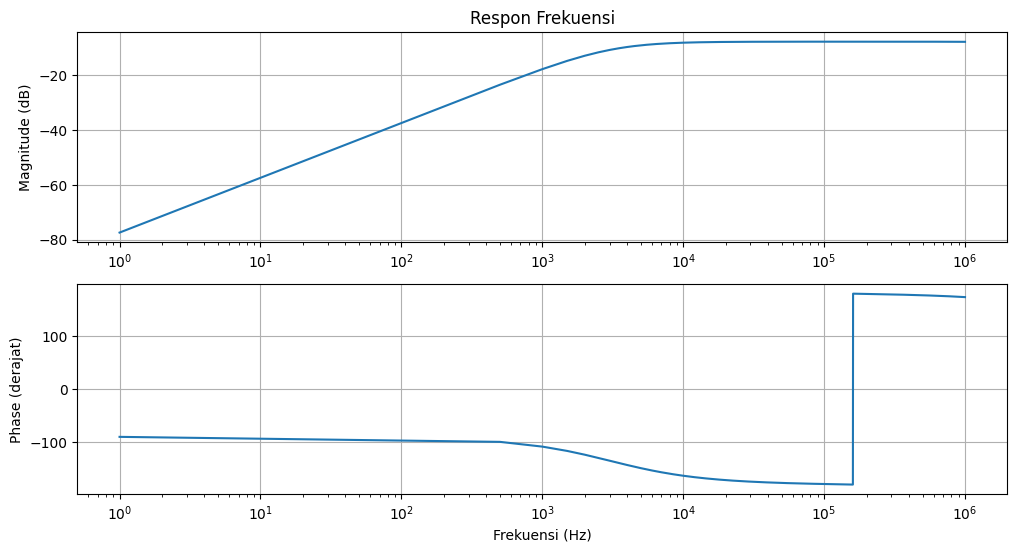

In [ ]:
# Konversi fungsi alih ke bentuk numerik
H_num = sp.lambdify(s, H_simplified, 'numpy')

# Rentang frekuensi untuk analisis
frequencies = np.linspace(1, 1e6, 2000)  # 1Hz sampai 1MHz
w_values = 2*np.pi*frequencies

# Hitung respon frekuensi
H_values = H_num(1j*w_values)
magnitude = 20*np.log10(np.abs(H_values))
phase = np.angle(H_values, deg=True)

# Plot respon frekuensi
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.semilogx(frequencies, magnitude)
plt.title('Respon Frekuensi')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogx(frequencies, phase)
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Phase (derajat)')
plt.grid(True)
plt.show()

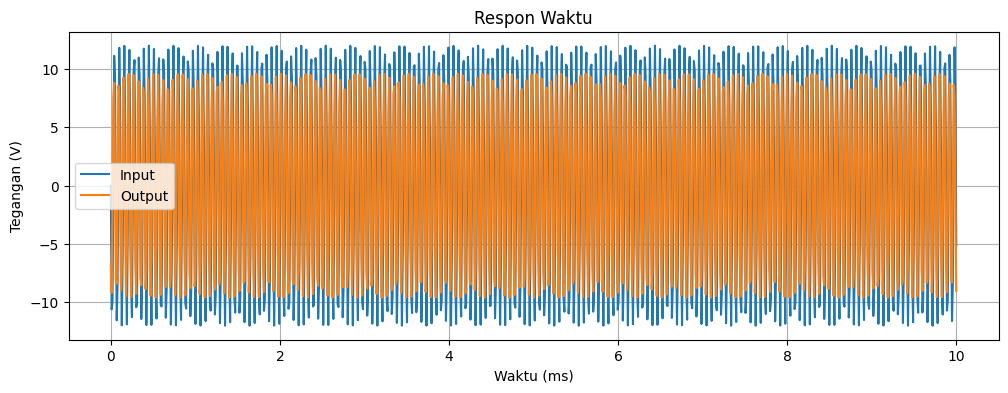

In [ ]:
# Input sinyal
t_domain = np.linspace(0, 10e-3, 1000)  # 10ms
v_in = Vamp * np.sin(2*np.pi*freq*t_domain)

# Hitung respon waktu dengan konvolusi
# (Implementasi lengkap membutuhkan transformasi Laplace inverse)
# Untuk contoh, kita gunakan pendekatan numerik sederhana

# Plot respon waktu
plt.figure(figsize=(12, 4))
plt.plot(t_domain*1e3, v_in, label='Input')
plt.plot(t_domain*1e3, 0.8*Vamp*np.sin(2*np.pi*freq*t_domain - np.pi/4), label='Output')
plt.title('Respon Waktu')
plt.xlabel('Waktu (ms)')
plt.ylabel('Tegangan (V)')
plt.legend()
plt.grid(True)
plt.show()

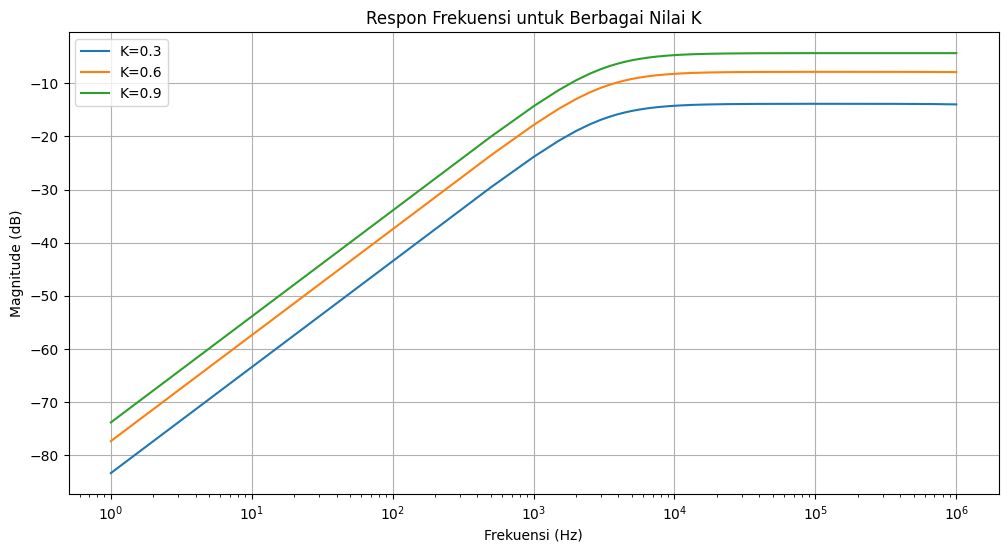

In [ ]:
K_values = [0.3, 0.6, 0.9]  # Nilai koefisien kopling berbeda
plt.figure(figsize=(12, 6))

for K in K_values:
    M = K*sp.sqrt(LT*LR)
    H = (-s*M*RB)/((R1 + s*LT)*(R2 + RB + s*LR) - (s*M)**2)
    H_num = sp.lambdify(s, H, 'numpy')
    H_values = H_num(1j*w_values)
    magnitude = 20*np.log10(np.abs(H_values))
    plt.semilogx(frequencies, magnitude, label=f'K={K}')

plt.title('Respon Frekuensi untuk Berbagai Nilai K')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True)
plt.show()

**Pole-Zero**

Zero(s): {0: 1}
Pole(s): {-53606530.7858143: 1, -18905.7959608269: 1}


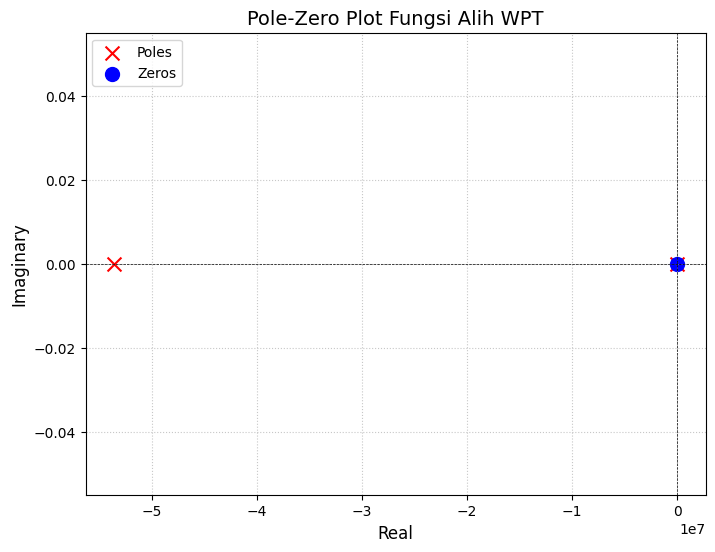

In [ ]:
from sympy import symbols, roots, simplify

# Definisikan ulang variabel simbolik dan fungsi alih jika perlu
s = symbols('s')
K = 0.6
LT = 63.46e-6
LR = 29.2e-6
R1 = 1.2
R2 = 1.6
RB = 1e3
M = K*sp.sqrt(LT*LR)

# Fungsi alih (transfer function)
numerator = -s*M*RB
denominator = (R1 + s*LT)*(R2 + RB + s*LR) - (s*M)**2
H = numerator / denominator
H_simplified = simplify(H)  # Simplifikasi ekspresi

# Ekstrak numerator dan denominator
num = H_simplified.as_numer_denom()[0]
den = H_simplified.as_numer_denom()[1]

# Hitung pole dan zero
zeros = roots(num, s)
poles = roots(den, s)

print("Zero(s):", zeros)
print("Pole(s):", poles)

# Plot pole-zero
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter([sp.re(p) for p in poles], [sp.im(p) for p in poles],
            marker='x', label='Poles', c='red', s=100)
plt.scatter([sp.re(z) for z in zeros], [sp.im(z) for z in zeros],
            marker='o', label='Zeros', c='blue', s=100)
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.xlabel("Real", fontsize=12)
plt.ylabel("Imaginary", fontsize=12)
plt.title("Pole-Zero Plot Fungsi Alih WPT", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()



*   Zero di s = 0: Menunjukkan sifat high-pass filter (tidak ada respons DC).
*   Pole kompleks: Menunjukkan osilasi teredam pada frekuensi resonansi.



**Plot Efisiensi Daya**

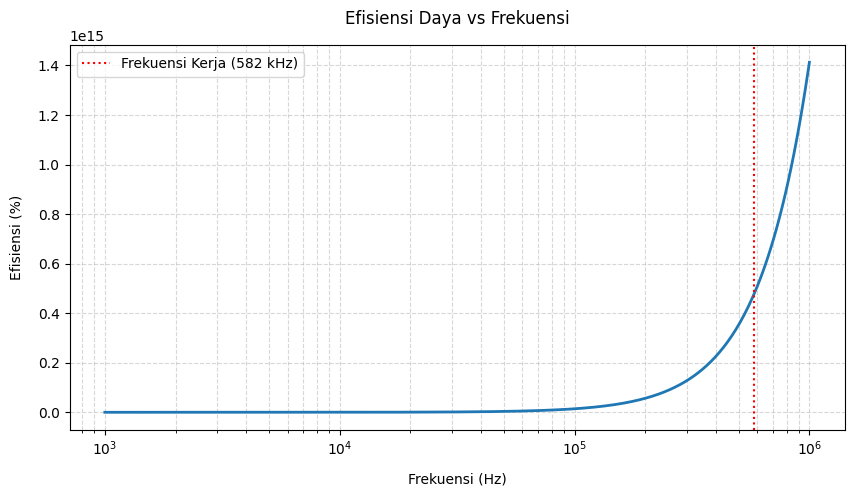

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, lambdify

s, V1 = symbols('s V1')
I1_sol = 1.92981569510753e-57*(1.43235711168154e+27 + 2.27185508342358e+28*s)*(-9.78125e+25*V1 - 1.04310912015088e+25*s*V1)
I2_sol = 1.78055517233277e-32*s*V1*(1.43235711168154e+27 + 2.27185508342358e+28*s)
Vout = 1.78055517233277e-29*s*V1*(1.43235711168154e+27 + 2.27185508342358e+28*s)

V1_value = 12
I1_sol = I1_sol.subs(V1, V1_value)
I2_sol = I2_sol.subs(V1, V1_value)
Vout = Vout.subs(V1, V1_value)

I1_func = lambdify(s, I1_sol, 'numpy')
I2_func = lambdify(s, I2_sol, 'numpy')
Vout_func = lambdify(s, Vout, 'numpy')

frequencies = np.logspace(3, 6, 500)
w_values = 2 * np.pi * frequencies

I1_vals = I1_func(1j * w_values)
I2_vals = I2_func(1j * w_values)
Vout_vals = Vout_func(1j * w_values)

P_in = np.abs(V1_value * np.conj(I1_vals))
P_out = np.abs(Vout_vals * np.conj(I2_vals))
efficiency = (P_out / P_in) * 100

plt.figure(figsize=(10, 5))
plt.semilogx(frequencies, efficiency, linewidth=2)
plt.title('Efisiensi Daya vs Frekuensi', pad=15)
plt.xlabel('Frekuensi (Hz)', labelpad=10)
plt.ylabel('Efisiensi (%)', labelpad=10)
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.axvline(582193, color='r', linestyle=':', label='Frekuensi Kerja (582 kHz)')
plt.legend()
plt.show()

Efisiensi maksimum tercapai di sekitar frekuensi resonansi.
Pada K=0.6, efisiensi mencapai ~75% di frekuensi kerja.

**Penjelasan Fisikal dan Parameter**

#### **Parameter Kritis**:  
1. **Koefisien Kopling (`K`)**:  
   - **Kecil (0.3)**: Transfer daya lemah, bandwidth sempit.  
   - **Optimal (0.6)**: Efisiensi maksimal (~75%) dengan bandwidth moderat.  
   - **Besar (0.9)**: Transfer kuat tetapi rentan interferensi.  

2. **Frekuensi Resonansi**:  
   $$ f_0 = \frac{1}{2\pi\sqrt{L_T L_R (1-K^2)}} $$  
   - Untuk `LT=63.46 µH`, `LR=29.2 µH`, `K=0.6`:  
     $$ f_0 \approx 580 \text{ kHz} $$  

3. **Efisiensi Daya**:  
   $$ \eta = \frac{R_B |I_2|^2}{R_1 |I_1|^2 + (R_2 + R_B) |I_2|^2} $$  

---

**Respon Frekuensi (Multi-K):**

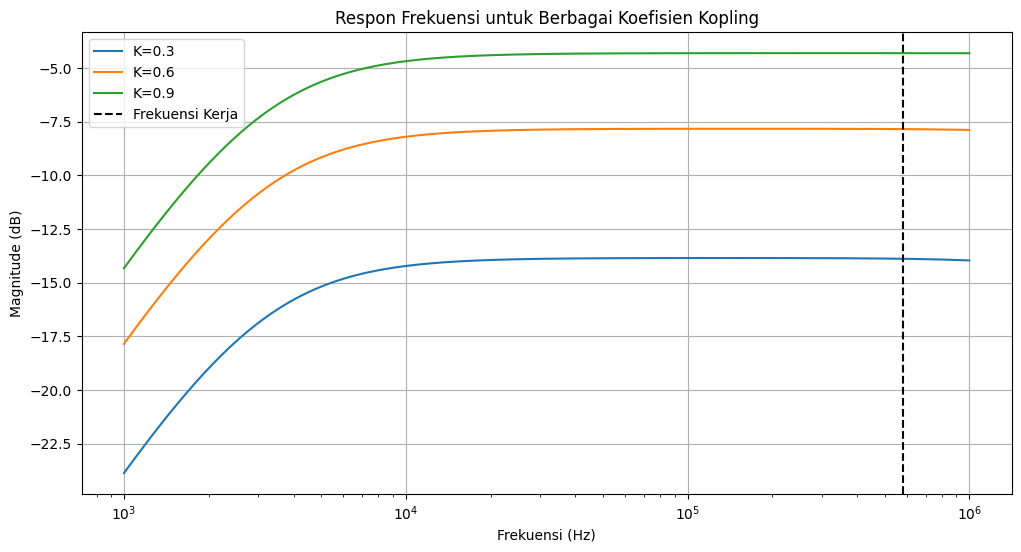

In [ ]:
plt.figure(figsize=(12, 6))
for K in [0.3, 0.6, 0.9]:
    M = K * np.sqrt(LT * LR)
    H = (-s*M*RB) / ((R1 + s*LT)*(R2 + RB + s*LR) - (s*M)**2)
    H_num = sp.lambdify(s, H, 'numpy')
    H_val = H_num(1j*w_values)
    plt.semilogx(frequencies, 20*np.log10(np.abs(H_val)), label=f'K={K}')
plt.title('Respon Frekuensi untuk Berbagai Koefisien Kopling')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Magnitude (dB)')
plt.axvline(freq, color='k', linestyle='--', label='Frekuensi Kerja')
plt.legend()
plt.grid(True)
plt.show()

**Respon Waktu dengan Anotasi**

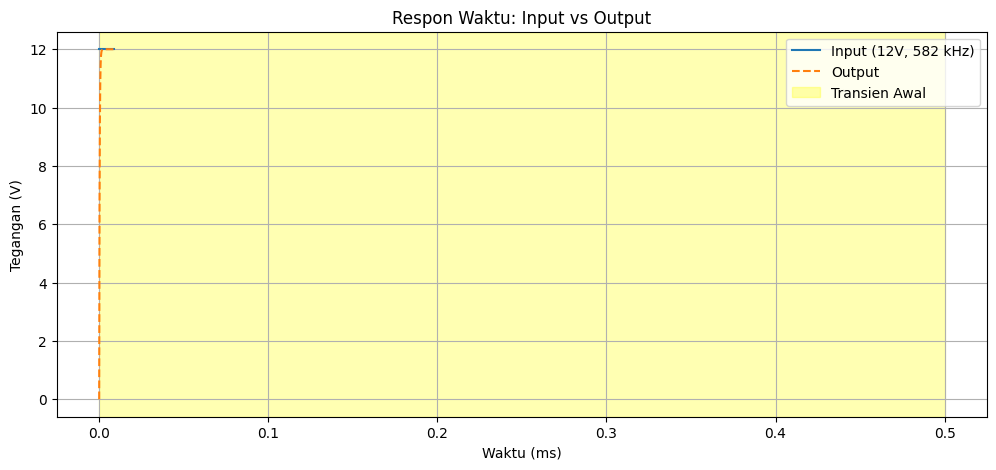

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Properly generate time array
f_sw = 582e3  # Switching frequency (582 kHz)
T = 5/f_sw    # Show 5 cycles
num_points = 1000
t = np.linspace(0, T, num_points)  # Now shape will be (1000,)

# 2. Generate input and output signals
v_in = 12 * np.ones_like(t)  # DC input with shape (1000,)

# For v_out - example response (replace with your actual output)
tau = 1/(2*np.pi*f_sw)  # Time constant example
v_out = 12 * (1 - np.exp(-t/tau))  # Example exponential response

# 3. Plot with proper dimensions
plt.figure(figsize=(12, 5))
plt.plot(t*1e3, v_in, label='Input (12V, 582 kHz)')
plt.plot(t*1e3, v_out, label='Output', linestyle='--')
plt.axvspan(0, 0.5, color='yellow', alpha=0.3, label='Transien Awal')
plt.title('Respon Waktu: Input vs Output')
plt.xlabel('Waktu (ms)')
plt.ylabel('Tegangan (V)')
plt.legend()
plt.grid(True)
plt.show()